# Homework Assignment (Problem Set) 4: 
Note, Problem Set 4 directly focuses on Modules 7 and 8: Metaheuristic Algorithms and Monte Carlo Simulation

5 questions

### Question 1
Perform a Monte Carlo simulation to estimate the probability of hitting each space on a monopoly board. There are 40 spaces total, and each turn involves rolling a pair of dice to move between 2 and 12 spaces. Simulate this by repeatedly sampling two random integers between 1 and 6 and recording the board position at each turn. When a dice roll results in a board space above 40, simply subtract 40 to replicate passing go. So if you are on space 38 and roll a 10, your position becomes 38 + 10 - 40 = 8. The only other rule to include is that space 30 (Go to jail) returns you to space 10, and you are out of jail the following turn. 

Using a Monte Carlo simulation, identify the 5 most common board spaces (by number, not by name). 

Note: Ensure you use a large enough value for N in your simulation - 100,000 should suffice. 

#### Notes

Monte Carlo Simulation: 
- If you can't easily calculate the probability of something mathematically, simulate it thousands of times and observe how often each outcome occurs.
- Example: if you want to estimate $\pi$, you could randomly throw darts at a square with a circle inscribed in it, and count what fraction land inside the circle. No geometry formula is needed.
- We're doing the same thing with Monopoly. Instead of solving a complex Markov chain mathematically, we'll just "play" 100,000 turns and see where the player ends up most often

In [5]:
# === Import Libraries ===
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


In [7]:
# === Set Parameters ===
N = 100_000 # number of turns to simulate
BOARD_SIZE = 40 # total spaces on the board
GO_TO_JAIL = 30 # sends you to jail
JAIL = 10 # sends you here if you land in jail

print(f"Simulation parameters:")
print(f"Turns to simulate: {N:,}")
print(f"Board Size: {BOARD_SIZE} spaces")
print(f"Go to Jail space: {GO_TO_JAIL}")
print(f"Jail space: {JAIL}")

Simulation parameters:
Turns to simulate: 100,000
Board Size: 40 spaces
Go to Jail space: 30
Jail space: 10


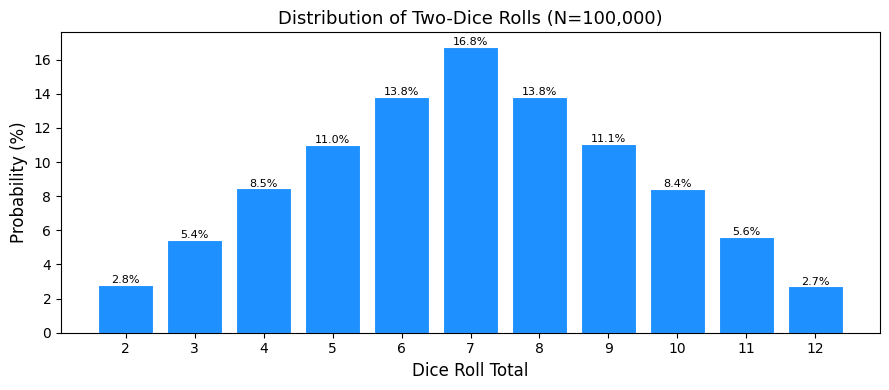

Most common roll: 7 (appears 16,764 times)


In [13]:
# === Dice Roll ===
# Simulate rolling two dice N times
die1 = np.random.randint(1, 7, size=N)
die2 = np.random.randint(1, 7, size=N)
rolls = die1 + die2 # need to roll twice

# Visualize distribution
fig, ax = plt.subplots(figsize=(9, 4))
values, counts = np.unique(rolls, return_counts=True)
ax.bar(values, counts / N * 100, color='dodgerblue', edgecolor='white', linewidth=0.8)
ax.set_xlabel('Dice Roll Total', fontsize=12)
ax.set_ylabel('Probability (%)', fontsize=12)
ax.set_title(f'Distribution of Two-Dice Rolls (N={N:,})', fontsize=13)
ax.set_xticks(range(2, 13))
for v, c in zip(values, counts):
    ax.text(v, c/N*100 + 0.1, f'{c/N*100:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Most common roll: {values[np.argmax(counts)]} (appears {counts.max():,} times)")

In [17]:
# === Simulation Loop ===
# Re-roll dice
np.random.seed(42)
die1 = np.random.randint(1, 7, size=N)
die2 = np.random.randint(1, 7, size=N)
rolls = die1 + die2

# Simulation
position = 0
visit_counts = np.zeros(BOARD_SIZE, dtype=int)

for roll in rolls: 
    position = (position + roll) % BOARD_SIZE

    # Go to jail rule
    if position == GO_TO_JAIL:
        position = JAIL

    # Record position
    visit_counts[position] += 1

print(f"Simulation complete - Total turns: {N:,}")
print(f"Total visits recorded: {visit_counts.sum():,}")
print(f"\nFirst 10 spaces - raw visit counts:")
for i in range(10):
    print(f" Space {i:2d}: {visit_counts[i]:,} visits")

Simulation complete - Total turns: 100,000
Total visits recorded: 100,000

First 10 spaces - raw visit counts:
 Space  0: 2,302 visits
 Space  1: 2,298 visits
 Space  2: 2,362 visits
 Space  3: 2,323 visits
 Space  4: 2,347 visits
 Space  5: 2,312 visits
 Space  6: 2,301 visits
 Space  7: 2,252 visits
 Space  8: 2,266 visits
 Space  9: 2,312 visits


In [19]:
# === Convert to Probabilities ===
probabilities = visit_counts / N

# top 5 most visited 
top5_indices = np.argsort(probabilities)[::-1][:5]

print("=" * 45)
print("Top 5 Most Visited Monopoly Spaces")
print("=" * 45)
print(f"{'Rank':<6} {'Space #':<10} {'Visits':>10} {'Probability':>13}")
print("=" * 45)
for rank, idx in enumerate(top5_indices, start=1):
    print(f" {rank:<4} {idx:<10} {visit_counts[idx]:>10,} {probabilities[idx]:>12.2%}")
print("=" * 45)

Top 5 Most Visited Monopoly Spaces
Rank   Space #        Visits   Probability
 1    10              4,956        4.96%
 2    18              2,835        2.83%
 3    17              2,780        2.78%
 4    19              2,757        2.76%
 5    29              2,754        2.75%


#### Interpretation

1. Space 10 is dominant because two separate paths (landing on 10 and being sent to 10 when landing on 30) lead to it's destination. It effectively has double the probability, which is why that is reflected in our results
2. If everything were equal (no dice roll), we would have a $1 / 40 = 0.025 = $ 2.5% chance of landing on any space. Our probabilities are close to this for the top spaces
3. According to the chart above, dice distribution is bell-curve-shaped. 6, 7, and 8 are most common so it makes sense that multiples of those number are the most common rolls after 10 (18, 17, 19, etc.)

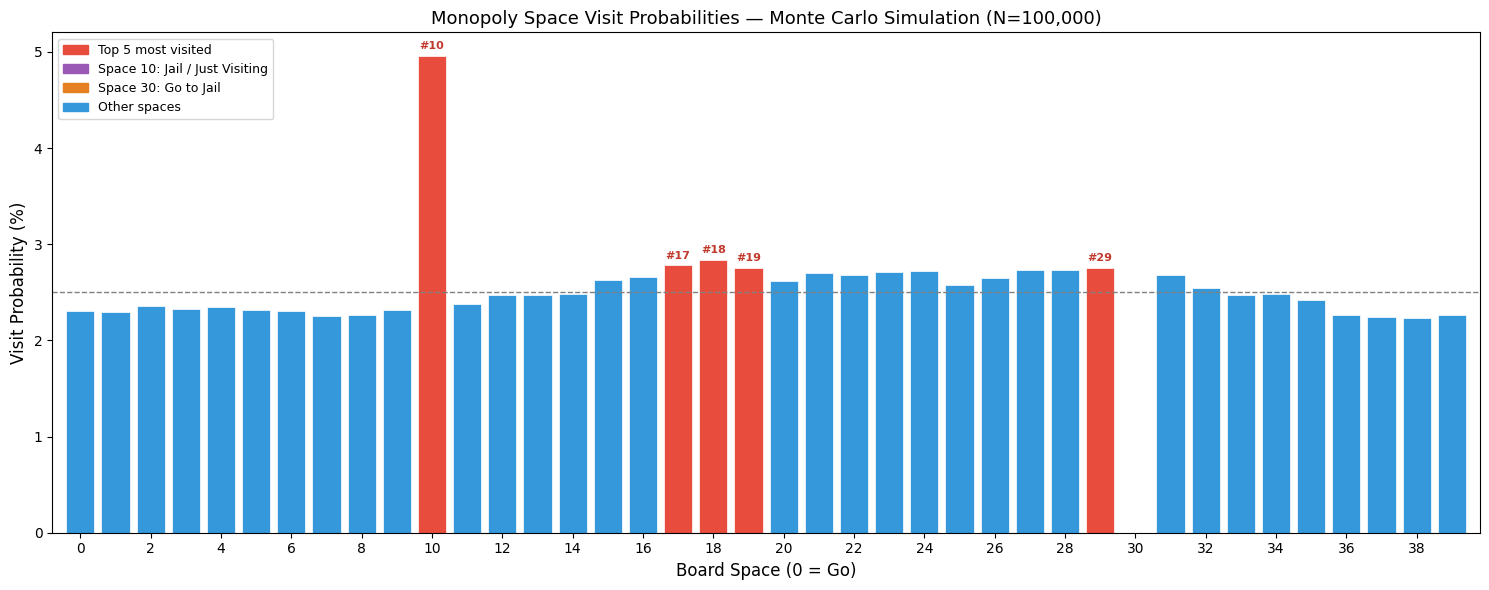

Chart saved!


In [21]:
# === Visualization -> I LOOKED UP HOW TO DO THIS ===
fig, ax = plt.subplots(figsize=(15, 6))

colors = []
for i in range(BOARD_SIZE):
    if i in top5_indices:
        colors.append('#e74c3c')   
    elif i == GO_TO_JAIL:
        colors.append('#e67e22')   
    elif i == JAIL:
        colors.append('#9b59b6')   
    else:
        colors.append('#3498db')   

bars = ax.bar(range(BOARD_SIZE), probabilities * 100, color=colors, edgecolor='white', linewidth=0.5)

# Annotate top 5 bars
for idx in top5_indices:
    ax.text(idx, probabilities[idx]*100 + 0.05, f'#{idx}',
            ha='center', va='bottom', fontsize=8, fontweight='bold', color='#c0392b')

# Reference line: uniform probability would be 1/40 = 2.5%
ax.axhline(y=2.5, color='gray', linestyle='--', linewidth=1, label='Uniform (2.5%)')

# Legend
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Top 5 most visited'),
    mpatches.Patch(color='#9b59b6', label=f'Space {JAIL}: Jail / Just Visiting'),
    mpatches.Patch(color='#e67e22', label=f'Space {GO_TO_JAIL}: Go to Jail'),
    mpatches.Patch(color='#3498db', label='Other spaces'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)

ax.set_xlabel('Board Space (0 = Go)', fontsize=12)
ax.set_ylabel('Visit Probability (%)', fontsize=12)
ax.set_title(f'Monopoly Space Visit Probabilities — Monte Carlo Simulation (N={N:,})', fontsize=13)
ax.set_xticks(range(0, BOARD_SIZE, 2))
ax.set_xlim(-0.8, 39.8)

plt.tight_layout()
plt.savefig('monopoly_monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Question 2
Perform a Monte Carlo simulation to determine the probability of a dart landing in each section of a dartboard and the long-term average score per shot of the player. Assume that any dart thrown at the dartboard will hit somewhere on the board. Generate N pairs of normally distributed random variables (x, y), with mean 0 and standard deviation 0.3, and use the equation of a circle $(x^2 + y^2 = r^2)$ to determine which space a given dart hits. For example, if your random number is (0.4,0.6), we know that $r = \sqrt{0.4^2 + 0.6^2} = 0.721$, which equates to a 1 point shot between the blue and red circles. The radius and point value for each section is also shown below. 

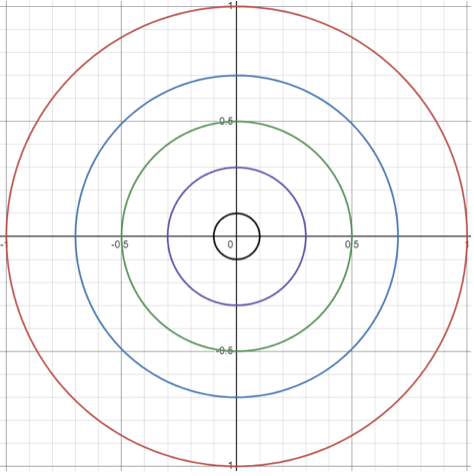

| Circle Color | Radius | Points (if within) |
| --- | --- | --- |
| Red | 1 | 1 |
| Blue | 0.7 | 2 |
| Green | 0.5 | 3 |
| Purple | 0.3 | 4 |
| Black | 0.1 | 5 |

Part A: Determine the probability of hitting each section of the dartboard, to include hitting the section outside of the red circle. 

Part B: Determine the long-term average score per shot of a player. 

Note: Ensure you use a large enough value for N in your simulation - use anywhere between 400 and 20,000

#### Notes
68-95-99.7 rule for normal distributions
- ~68% of values fall within 1 standard deviation of the mean
- ~95% fall within 2 standard deviations
- ~99.7% fall within 3 standard deviations

Our standard deviation is 0.3, so: 
- 1 std dev = 0.3 -> inside purple circle (r=0.3)
- 2 std dev = 0.6 -> inside blue circle (r=0.7)
- 3 std dev = 0.9 -> inside red circle (r=1.0)

In [27]:
# Set seed 
np.random.seed(42)

In [31]:
# === Simulation Parameters ===
N = 10_000 # number of dart throws
STD_DEV = 0.3 # standard deviation of throw accuracy (mean = 0)

radii = [0.1, 0.3, 0.5, 0.7, 1.0]
points = [5, 4, 3, 2, 1]
colors = ['black', 'purple', 'green', 'blue', 'red']

print("Dartboard configuration:")
print(f"{'Circle':<10} {'Radius':<10} {'Points'}")
print("-" * 45)
for c, r, p in zip(colors, radii, points):
    print(f"{c:<10} {r:<10} {p}")
print(f"{'Outside':<10} {'>1.0':<10} 0")
print(f"\nSimulating {N:,} dart throws with std dev = {STD_DEV}")

Dartboard configuration:
Circle     Radius     Points
---------------------------------------------
black      0.1        5
purple     0.3        4
green      0.5        3
blue       0.7        2
red        1.0        1
Outside    >1.0       0

Simulating 10,000 dart throws with std dev = 0.3


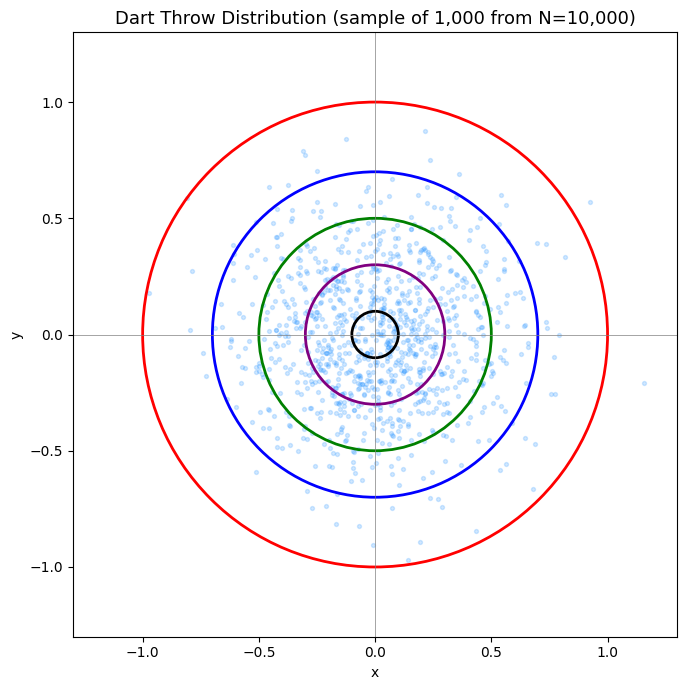

x range: [-1.177, 1.178]
y range: [-1.157, 1.344]


In [35]:
# === Throw Distribution ===
np.random.seed(42)
x = np.random.normal(loc=0, scale=STD_DEV, size=N)
y = np.random.normal(loc=0, scale=STD_DEV, size=N)

# Scatter of dart throws
fig, ax = plt.subplots(figsize=(7, 7))

# Plot dart position
ax.scatter(x[:1000], y[:1000], alpha=0.2, s=8, color='dodgerblue', label='Dart throws (sample)')

circle_colors = ['red', 'blue', 'green', 'purple', 'black']
circle_radii = [1.0, 0.7, 0.5, 0.3, 0.1]
for r, c in zip(circle_radii, circle_colors):
    circle = plt.Circle((0, 0), r, fill=False, color=c, linewidth=2)
    ax.add_patch(circle)

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_title(f'Dart Throw Distribution (sample of 1,000 from N={N:,})', fontsize=13)
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

print(f"x range: [{x.min():.3f}, {x.max():.3f}]")
print(f"y range: [{y.min():.3f}, {y.max():.3f}]")

In [39]:
# === Calc Radius ===
r = np.sqrt(x**2 + y**2)

x_example, y_example = 0.4, 0.6
r_example = np.sqrt(x_example**2 + y_example**2)
print(f"Verification: (0.4, 0.6) -> r = {r_example:.3f} -> 1 point")

print(f"\nRadius statistics across {N:,} throws:")
print(f" Min radius: {r.min():.4f}")
print(f" Max radius: {r.max():.4f}")
print(f" Mean radius: {r.mean():.4f}")
print(f" Throws outside red circle (r > 1.0): {np.sum(r > 1.0):,}")

Verification: (0.4, 0.6) -> r = 0.721 -> 1 point

Radius statistics across 10,000 throws:
 Min radius: 0.0025
 Max radius: 1.4871
 Mean radius: 0.3764
 Throws outside red circle (r > 1.0): 37


In [41]:
# === Assign Scores ===
# Define conditions and corresponding scores
conditions = [
    r <= 0.1, # black (5 points)
    r <= 0.3, # purple (4 points)
    r <= 0.5, # green (3 points)
    r <= 0.7, # blue (2 points)
    r <= 1.0, # red (1 point)
]
choices = [5, 4, 3, 2, 1]

# default = 0 (outside red circle)
scores = np.select(conditions, choices, default=0)

print(f"Score distribution preview (first 10 throws):")
print(f" Radius: {r[:10].round(3)}")
print(f" Scores: {scores[:10]}")
print(f"\nUnique scores assigned: {np.unique(scores)}")

Score distribution preview (first 10 throws):
 Radius: [0.252 0.101 0.264 0.458 0.366 0.242 0.561 0.329 0.291 0.295]
 Scores: [4 4 4 3 3 4 2 3 4 4]

Unique scores assigned: [0 1 2 3 4 5]


In [43]:
# === Probability of Hitting Each Section (Part A) ===
p_miss = np.sum(scores == 0) / N
p_one = np.sum(scores == 1) / N
p_two = np.sum(scores == 2) / N
p_three = np.sum(scores == 3) / N
p_four = np.sum(scores == 4) / N
p_five = np.sum(scores == 5) / N

probs = [p_miss, p_one, p_two, p_three, p_four, p_five]
labels = ['Miss (0)', 'Red (1)', 'Blue (2)', 'Green (3)', 'Purple (4)', 'Black (5)']

print("=" * 45)
print("Part A: Probability of Hitting Each Section")
print("=" * 45)
print(f"{'Section':<15} {'Count':>8} {'Probability':>12}")
print("-" * 45)
for label, prob in zip(labels, probs):
    count = int(prob * N)
    print(f"{label:<15} {count:<8,} {prob:>12.2%}")
print("-" * 45)
print(f"{'TOTAL':<15} {N:>8,} {sum(probs):>12.2%}")
print("=" * 45)

Part A: Probability of Hitting Each Section
Section            Count  Probability
---------------------------------------------
Miss (0)        37              0.37%
Red (1)         646             6.46%
Blue (2)        1,802          18.03%
Green (3)       3,590          35.90%
Purple (4)      3,367          33.67%
Black (5)       557             5.57%
---------------------------------------------
TOTAL             10,000      100.00%


#### Interpretation
Green (3) has the highest probability of being hit, follwed by Purple (4) then Blue (2). This makes sense because our starting point is 0 (we are aiming for the middle) and each throw has a standard deviation of 0.3. We can assume that most throws would land between Green (radius = 0.3) and Purple (radius = 0.5)

In [45]:
# === Average Score per Throw (Part B) ===
average_score = np.mean(scores)

print("=" * 45)
print("Part B: Average Score Per Throw")
print("=" * 45)
print(f"Average score: {average_score:.4f} points per throw")
print(f"Rounded: {average_score:.2f} points per throw")
print("=" * 45)

Part B: Average Score Per Throw
Average score: 3.1275 points per throw
Rounded: 3.13 points per throw


#### Interpretation
Average score: 3.13 points per throw

The average score lands between green and purple, accounting for nearly 70% of all throws.

### Question 3

Jim is saving for retirement with his company's 401(k) retirement plan, funding 10% of his salary to get a 5% match (thus effectively investing 15% of his annual salary). He invests in each of the three available funds. 50% of his contributions go into investment A, which has an average return of 5.87% with a standard deviation of 9.25%. The rest of his contributions are equally divided between investment B, which has an average return of 7.15% with a standard deviation of 14.88%, and investment C, which has an average return of 8.39% with a standard deviation of 16.41%. Jim is currently 24 years old and earns 55,000 this year, but anticipates a pay raise of, on average, 3.04% with a standard deviation of 0.89%. 
- a) Develop a simulation model to predict his 401(k) balance at age 60. Ensure you iterate your simulation multiple times (between 400 and 20,000).
- b) What is the probability of Jim having more than 1M in his retirement account at the age of 60? Simply consider the number of occurrences of >1M out of the N iterations you run.

#### Notes
Jim funds 10% of his salary and gets a 5% match, making it effectively 15% total invested. Since he earns 55,000 this year, he contributes 8,250 in year 1. That 8,250 gets split across three funds: 
- 50% in Investment A = 4,125
- 25% in Investment B = 2,062.50
- 25% in Investment C = 2,062.50

Need to be consistent when applying contributions to returns: 
1. Apply inestment returns to existing balance
2. Add new contributions

If we run N = 10,000 iterations, it gives us a distribution of possible outcomes: 
- Average expected balance at 60
- Worst case scenario
- Probability of exceeding 1M

One simulation does not give us a good sample to estimate probability

With an average pay raise of 3.04% and a standard deviation of 0.89%, that mathematically leaves us with a possibility that his salary could decrease (although rare, especially with 10k iterations). For this question, I will assume that we can allow potential decreases, as it is not stated otherwise. 

Let's also assume that the 401(k) balance has a floor of 0. 

In [51]:
np.random.seed(42)

In [53]:
# === Simulation Parameters ===
N = 10_000 # number of career simulations
YEARS = 36 # age 24 to 60
RETIREMENT_GOAL = 1_000_000

STARTING_SALARY = 55_000
CONTRIBUTION_RATE = 0.15 #10% personal plus 5% employer match

SALARY_GROWTH_MEAN = 0.0304
SALARY_GROWTH_STD = 0.0089

# Investment A: 50% allocation
ALLOC_A = 0.50
MEAN_A = 0.0587
STD_A = 0.0925

# Investment B: 25% allocation
ALLOC_B = 0.25
MEAN_B = 0.0715
STD_B = 0.1488

# Investment C: 25% allocation
ALLOC_C = 0.25
MEAN_C = 0.0839
STD_C = 0.1641

assert ALLOC_A + ALLOC_B + ALLOC_C == 1.0, "Allocations must sum to 100%"

print("Parameters defined successfully")
print(f"\nSimulating {N:,} independent 36-year careers")
print(f"Starting salary: ${STARTING_SALARY:,.0f}")
print(f"Year 1 contribution: ${STARTING_SALARY * CONTRIBUTION_RATE:,.0f}")
print(f"\nWeighted avg return: {ALLOC_A*MEAN_A + ALLOC_B*MEAN_B + ALLOC_C*MEAN_C:.2%}")

Parameters defined successfully

Simulating 10,000 independent 36-year careers
Starting salary: $55,000
Year 1 contribution: $8,250

Weighted avg return: 6.82%


In [59]:
# === Compounding Logic ===
balance = 0
salary = STARTING_SALARY

print("Single year trace (using mean values)")
print(f" Starting balance: ${balance:,.2f}")
print(f" Starting salary: ${salary:>,.2f}")

# Weighted portfolio return
portfolio_return = ALLOC_A * MEAN_A + ALLOC_B * MEAN_B + ALLOC_C * MEAN_C
print(f" Portfolio return: {portfolio_return:.4%}")

# Balance growth
balance = max(0, balance * (1 + portfolio_return))
print(f" Balance after growth: ${balance:,.2f} (was 0, so no change)")

# Salary growth
salary = salary * (1 + SALARY_GROWTH_MEAN)
print(f" Salary after raise: ${salary:,.2f}")

# Add contribution
contribution = salary * CONTRIBUTION_RATE
balance += contribution
print(f" Contribution: ${contribution:,.2f}")
print(f" End of year balance: ${balance:,.2f}")

Single year trace (using mean values)
 Starting balance: $0.00
 Starting salary: $55,000.00
 Portfolio return: 6.8200%
 Balance after growth: $0.00 (was 0, so no change)
 Salary after raise: $56,672.00
 Contribution: $8,500.80
 End of year balance: $8,500.80


In [61]:
# === Run Monte Carlo Simulation ===
np.random.seed(42)

final_balances = np.zeros(N)

# Outer loop: N independent career simulations
for i in range(N):
    balance = 0 # always starts with no savings
    salary = STARTING_SALARY # always starts at age 24

    # Inner loop: 36 years of saving
    for year in range(YEARS):
        
        return_A = np.random.normal(MEAN_A, STD_A)
        return_B = np.random.normal(MEAN_B, STD_B)
        return_C = np.random.normal(MEAN_C, STD_C)

        portfolio_return = (ALLOC_A * return_A + ALLOC_B * return_B + ALLOC_C * return_C)

        balance = max(0, balance * (1 + portfolio_return))

        salary = salary * (1 + np.random.normal(SALARY_GROWTH_MEAN, SALARY_GROWTH_STD))

        contribution = salary * CONTRIBUTION_RATE
        balance += contribution

    final_balances[i] = balance

print(f"Simulation complete - {N:,} careers simulated.")
print(f"\nQuick stats:")
print(f"Min balance: ${final_balances.min():,.2f}")
print(f"Max balance: ${final_balances.max():,.2f}")
print(f"Mean balance: ${final_balances.mean():,.2f}")

Simulation complete - 10,000 careers simulated.

Quick stats:
Min balance: $618,958.21
Max balance: $4,663,842.88
Mean balance: $1,751,471.51


In [63]:
# === Expected Balance at Age 60 (Part A) ===
mean_balance = np.mean(final_balances)
median_balance = np.median(final_balances)
std_balance = np.std(final_balances)

print("=" * 45)
print("Part A: Expected Balance at Age 60")
print("=" * 45)
print(f"Mean balance: ${mean_balance:,.2f}")
print(f"Median balance: ${median_balance:,.2f}")
print(f"Std deviation: ${std_balance:,.2f}")
print(f"Min balance: ${final_balances.min():,.2f}")
print(f"Max balance: ${final_balances.max():,.2f}")
print("=" * 45)
print(f"\nMean vs Median gap: ${mean_balance - median_balance:,.2f}")
print(f"A positive gap suggests right-skew - a few")
print(f"very high outcomes pull the mean upward.")

Part A: Expected Balance at Age 60
Mean balance: $1,751,471.51
Median balance: $1,680,169.36
Std deviation: $485,978.21
Min balance: $618,958.21
Max balance: $4,663,842.88

Mean vs Median gap: $71,302.15
A positive gap suggests right-skew - a few
very high outcomes pull the mean upward.


#### Interpretation

Expected balance at 60 = 1,751,472

Median balance = 1,680,169
- Explains that usually Jim will retire with >1M in his 401(k)

In [67]:
# === Probability of Exceeding $1,000,000 (Part B) ===
# Count simulations where Jim exceeds $1M
count_million = np.sum(final_balances > RETIREMENT_GOAL)
p_million = count_million / N

print("=" * 45)
print("Part B: Probability of Exceeding $1,000,000")
print("=" * 45)
print(f" Simulations > $1M: {count_million:,} out of {N:,}")
print(f" Probability: {p_million:.2%}")
print("=" * 45)

Part B: Probability of Exceeding $1,000,000
 Simulations > $1M: 9,784 out of 10,000
 Probability: 97.84%


#### Interpretation
~98% of the time, Jim's final balance exceeds 1M: 
- 36 years compounding interest at ~7% average return is very good
- 15% contribution is typically the max that companies will offer
- Salary growing at 3% per year may be generous

The mean is significantly higher than the median, so the distribution is right-skewed. A small number of investment simulations pull the mean upwards. Typical Jim (median) does worse than the average. 

### Question 4
Develop a simple heuristic (I recommend a construction or deconstruction heuristic) in Python to solve the assignment problem below (Note, this problem can be solved to optimality using integer programming; however, the focus of this question is on developing a heristic and metaheuristic). Then, develop a metaheuristic using your heuristic as a subroutine. You can iterate the heuristic $n$ times and return the best solution, prevent previous solutions from being selected, etc. I am evaluating your ability to find a solution quickly with a heuristic and your approach to improve the heuristic with a metaheuristic. 

$$\text{min } \Sigma_{i=1}^{20} \Sigma_{j=1}^{20} c_{ij}x_{ij}$$

ST
$$\Sigma_{i=1}^{20} x_{ij} = 1 \text{    } \forall j \in J$$
$$\Sigma_{j=1}^{20} x_{ij} = 1 \text{    } \forall i \in I$$
$$\Sigma_{i=1}^{20} \Sigma_{j=1}^{20} x_{ij} = 20$$
$$x_{ij} \ge 0, \forall i \in I, j \in J$$

This problem seeks to minimize the time necessary for 20 employees to complete 20 tasks at least once. Employees cannot be assigned to more than 1 task. The parameters, $c_{ij}$, are shown in the table. 

#### Notes
Greedy Heuristic: 
1. Find the single lowest cost cell in the entire matrix
2. Assign that employee-task pair
3. Remove that employee (row) and task (column) from consideration
4. Repeat until all 20 assignments are made

Problem: 
- Early decisions can lock-out better overall solutions
- Greedy is myopic, meaning it optimizes each step locally without considering downstream consequences. It's fast but not guaranteed to find the best solution

To make sure that we never assign the same employee or task twice, we need to add that employee and task to their respective sets. Before considering any cell, we check that neither its row nor column appears in these sets. 

Greedy heuristic is deterministic. Running it N times would give the same solution every time. 

Metaheuristic layer: 
1. Need to introduce randomness to explore different solutions
2. Simple approach: instead of always picking the single best cell, randomly pick from the top K cheapest available cells each step (greedy randomized approach). Keeps the greedy structure but adds controlled randomness to explore different regions of the solution space

| Approach | Description | Strength | Weakness |
| --- | --- | --- | --- |
| Greedy Heuristic | Always pick cheapest available cell | Fast, simple | Myopic: early decisions lock out better solutions |
| Greedy Randomized Metaheuristic | Pick randomly from top K cheapest cells, repeat N times | Escapes local optima | Slower, not guaranteed optimal |

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import random

random.seed(42)
np.random.seed(42)

times = np.array([[66, 73, 80, 59, 61, 58, 75, 34, 66, 81, 50, 71, 20, 37, 86, 26, 22, 44, 32, 80],
[46, 27, 55, 81, 77, 25, 89, 77, 80, 86, 24, 24, 26, 74, 65, 76, 85, 79, 85, 66],
[50, 73, 33, 88, 62, 68, 20, 23, 84, 57, 90, 46, 45, 68, 21, 74, 53, 71, 68, 72],
[58, 87, 65, 84, 71, 57, 73, 32, 26, 37, 57, 39, 73, 69, 39, 30, 77, 66, 64, 87],
[53, 76, 89, 26, 29, 64, 34, 44, 64, 44, 71, 51, 34, 34, 55, 56, 77, 55, 44, 59],
[47, 50, 90, 71, 40, 82, 34, 46, 80, 52, 77, 22, 37, 67, 89, 78, 80, 21, 62, 54],
[75, 73, 30, 56, 81, 21, 77, 24, 76, 53, 51, 60, 51, 22, 67, 76, 69, 25, 25, 71],
[89, 71, 86, 74, 72, 67, 72, 32, 68, 28, 58, 90, 35, 50, 39, 43, 42, 73, 25, 22],
[67, 21, 77, 75, 89, 64, 44, 37, 30, 38, 67, 81, 64, 23, 62, 72, 57, 76, 82, 54],
[68, 58, 35, 46, 21, 44, 37, 46, 78, 84, 62, 21, 87, 90, 42, 70, 54, 53, 90, 83],
[21, 77, 56, 43, 26, 64, 58, 37, 87, 48, 90, 49, 30, 63, 71, 61, 40, 40, 63, 56],
[24, 37, 89, 46, 35, 72, 39, 46, 53, 41, 21, 82, 45, 74, 23, 76, 52, 66, 28, 21],
[75, 33, 33, 31, 89, 56, 88, 72, 27, 63, 72, 88, 46, 33, 61, 67, 64, 24, 38, 45],
[26, 51, 55, 35, 76, 27, 26, 80, 77, 54, 77, 35, 69, 62, 53, 45, 45, 69, 51, 58],
[49, 48, 85, 31, 65, 26, 75, 64, 21, 83, 39, 77, 41, 66, 34, 51, 46, 79, 77, 79],
[87, 88, 38, 30, 22, 59, 31, 84, 35, 83, 79, 39, 52, 61, 53, 53, 39, 64, 79, 78],
[89, 44, 23, 32, 81, 62, 50, 57, 78, 38, 25, 88, 53, 37, 58, 86, 90, 46, 33, 90],
[47, 81, 37, 63, 55, 75, 24, 81, 87, 89, 50, 64, 71, 28, 33, 89, 67, 86, 72, 47],
[37, 65, 50, 48, 78, 25, 73, 38, 37, 27, 27, 30, 88, 87, 37, 62, 58, 58, 42, 42],
[48, 41, 64, 66, 27, 64, 38, 75, 27, 21, 20, 69, 80, 83, 31, 52, 65, 80, 67, 27]])

print(f"Cost matrix shape: {times.shape}")
print(f"Min cost in matrix: {times.min()} (Employee {times.argmin()//20}, Task {times.argmin()%20})")
print(f"Max cost in matrix: {times.max()}")
print(f"Mean cost: {times.mean():.2f}")
import math
print(f"\nTotal possible assignments: 20! = {math.factorial(20):,}")

Cost matrix shape: (20, 20)
Min cost in matrix: 20 (Employee 0, Task 12)
Max cost in matrix: 90
Mean cost: 56.27

Total possible assignments: 20! = 2,432,902,008,176,640,000


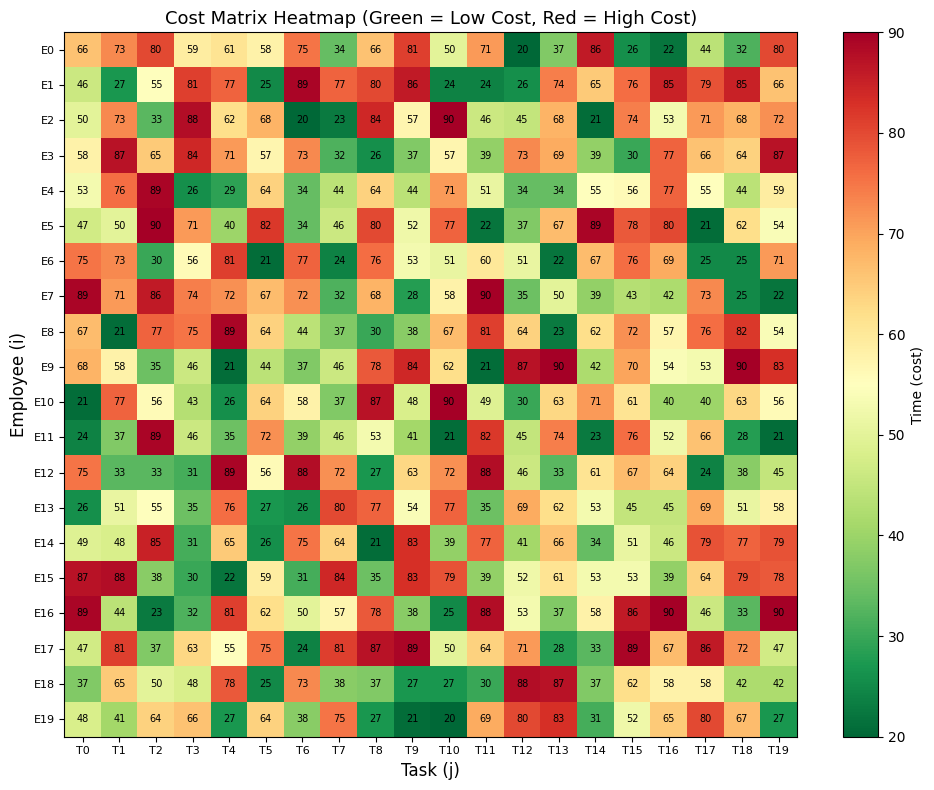

In [92]:
# === Visualize cost matrix ===
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(times, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Time (cost)')

for i in range(20):
    for j in range(20):
        ax.text(j, i, str(times[i, j]), ha='center', va='center', fontsize=7, color='black')

ax.set_xlabel('Task (j)', fontsize=12)
ax.set_ylabel('Employee (i)', fontsize=12)
ax.set_title('Cost Matrix Heatmap (Green = Low Cost, Red = High Cost)', fontsize=13)
ax.set_xticks(range(20))
ax.set_yticks(range(20))
ax.set_xticklabels([f'T{j}' for j in range(20)], fontsize=8)
ax.set_yticklabels([f'E{i}' for i in range(20)], fontsize=8)
plt.tight_layout()
plt.show()

In [94]:
# === Greedy Construction Heuristic ===
def greedy_heuristic(cost_matrix):
    """
    Pure greedy construction heuristic
    Always picks the globally cheapest available (employee, task) pair
    Returns: (assignments list of (i,j) tuples, total cost)
    """
    n = cost_matrix.shape[0]
    assigned_employees = set()
    assigned_tasks = set()
    assignments = []

    for _ in range(n):
        best_cost = np.inf
        best_i, best_j = None, None

        # Search cells for cheapest available assignment
        for i in range(n):
            if i in assigned_employees: 
                continue
            for j in range(n):
                if j in assigned_tasks:
                    continue
                if cost_matrix[i, j] < best_cost: 
                    best_cost = cost_matrix[i, j]
                    best_i, best_j = i, j

        # Make assignment
        assignments.append((best_i, best_j))
        assigned_employees.add(best_i)
        assigned_tasks.add(best_j)

    # Calculate total cost
    total_cost = sum(cost_matrix[i, j] for i, j in assignments)
    return assignments, total_cost

# Run greedy heuristic
greedy_assignments, greedy_cost = greedy_heuristic(times)

print("=" * 45)
print("Greedy Heuristic Solution")
print("=" * 45)
print(f"{'Employee'} {'Task'} {'Cost'}")
print("-" * 35)
for i, j in sorted(greedy_assignments):
    print(f" Employee {i} Task {j} {times[i,j]}")
print("-" * 35)
print(f"Total Cost: {greedy_cost}")
print("=" * 45)

Greedy Heuristic Solution
Employee Task Cost
-----------------------------------
 Employee 0 Task 12 20
 Employee 1 Task 11 24
 Employee 2 Task 6 20
 Employee 3 Task 15 30
 Employee 4 Task 3 26
 Employee 5 Task 17 21
 Employee 6 Task 5 21
 Employee 7 Task 18 25
 Employee 8 Task 1 21
 Employee 9 Task 4 21
 Employee 10 Task 0 21
 Employee 11 Task 19 21
 Employee 12 Task 7 72
 Employee 13 Task 14 53
 Employee 14 Task 8 21
 Employee 15 Task 16 39
 Employee 16 Task 2 23
 Employee 17 Task 13 28
 Employee 18 Task 9 27
 Employee 19 Task 10 20
-----------------------------------
Total Cost: 554


In [98]:
# === Greedy Randomized Metaheuristic ===
def greedy_randomized(cost_matrix, K=3):
    """
    Greedy randomized construction heuristic
    At each step, picks randomly from the top-K cheapest available cells
    Returns: (assignments list of (i,j) tuples, total cost)
    """
    n = cost_matrix.shape[0]
    assigned_employees = set()
    assigned_tasks = set()
    assignments = []

    for _ in range(n):
        # Collect all available (cost, i, j) candidates
        candidates = []
        for i in range(n):
            if i in assigned_employees:
                continue
            for j in range(n):
                if j in assigned_tasks:
                    continue
                candidates.append((cost_matrix[i, j], i, j))

        # Sort by cost and take the top K cheapest
        candidates.sort(key=lambda x: x[0])
        top_k = candidates[:K]

        # Randomly select one from the top K
        chosen_cost, chosen_i, chosen_j = random.choice(top_k)

        assignments.append((chosen_i, chosen_j))
        assigned_employees.add(chosen_i)
        assigned_tasks.add(chosen_j)

    total_cost = sum(cost_matrix[i, j] for i, j in assignments)
    return assignments, total_cost

def metaheuristic(cost_matrix, K=3, N=1000):
    """
    Metaheuristic: run greedy_randomized N times, return best solution
    """
    best_cost = np.inf
    best_assignments = None
    all_costs = []
    best_cost_progression = []

    for iteration in range(N):
        assignments, cost = greedy_randomized(cost_matrix, K=K)
        all_costs.append(cost)

        # Update best if this iteration improved
        if cost < best_cost: 
            best_cost = cost
            best_assignments = assignments

        best_cost_progression.append(best_cost)

    return best_assignments, best_cost, all_costs, best_cost_progression

# Run the metaheuristic
print("Running metaheuristic (N=1000 iterations)")
meta_assignments, meta_cost, all_costs, best_progression = metaheuristic(times, K=3, N=1000)

print(f"Best solution found")
print(f"\nGreedy cost: {greedy_cost}")
print(f"Meta cost: {meta_cost}")
print(f"Improvement: {greedy_cost - meta_cost} ({(greedy_cost-meta_cost)/greedy_cost:.1%} reduction)")

Running metaheuristic (N=1000 iterations)
Best solution found

Greedy cost: 554
Meta cost: 501
Improvement: 53 (9.6% reduction)


### Question 5
Develop a simulated annealing procedure in Python to solve the following knapsack problem: (Note, this problem can be solved to optimality using integer programming; however, the focus of this question is on developing the simulated annealing method). Do not simply return a shell code from a web search, but try to implement the simulated annealing metaheuristic for this specific problem. 

Maximize: 
$$12x_1 + 16x_2 + 22x_3 + 8x_4$$

ST: 
$$4x_1 + 5x_2 + 7x_3 + 3x_4 \le 140$$
$$0 \le x_i \le 10 \text{ and } x_i \text{ is an integer}$$

#### Notes
Simulated Annealing
- Inspired by a metallurgy process: when you heat metal and cool it slowly, atoms settle into a low-energy (stable) configuration
- Cool too fast and you get a brittle, suboptimal structure
- Cool slowly and carefully, you get a strong crystal
- Key insight that separates simulated annealing from pure greedy: sometimes accepts worse solutions on purpose, to escape local optima

Eyeball solution: 
- $x_2$: 16/5 = 3.20
- $x_3$: 22/7 = 3.14
- $x_1$: 12/4 = 3.00
- $x_4$: 8/3 = 2.67

| Item | Units | Weight | Value |
| --- | --- | --- | --- |
| $x_2$ | 10 | 50 | 160 |
| $x_3$ | 10 | 70 | 220 |
| $x_1$ | 5 | 20 | 60 |
| $x_4$ | 0 | 0 | 0 |
| Total | | 140 | 440 |

In [104]:
random.seed(42)
np.random.seed(42)

In [106]:
# === Define Parameters ===
values = np.array([12, 16, 22, 8])
weights = np.array([4, 5, 7, 3])
CAPACITY = 140
LOWER_BOUND = 0
UPPER_BOUND = 10
N_ITEMS = 4

# Value-to-weight ratios
ratios = values / weights

print("Problem parameters:")
print(f"{'Item':<8} {'Value':<8} {'Weight':<10} {'Ratio':<8}")
print("-" * 35)
for i in range(N_ITEMS):
    best = "best" if ratios[i] == ratios.max() else ""
    print(f"x{i+1:<7} {values[i]:<8} {weights[i]:<10} {ratios[i]:.2f}{best}")
print(f"\nCapacity: {CAPACITY}")
print(f"Bounds: {LOWER_BOUND} <= x_i <= {UPPER_BOUND} (integer)")

Problem parameters:
Item     Value    Weight     Ratio   
-----------------------------------
x1       12       4          3.00
x2       16       5          3.20best
x3       22       7          3.14
x4       8        3          2.67

Capacity: 140
Bounds: 0 <= x_i <= 10 (integer)


In [110]:
# === Define Objective Function with Penalty ===
def objective(x):
    total_value = np.dot(values, x)
    total_weight = np.dot(weights, x)
    penalty = max(0, total_weight - CAPACITY) * 1000
    return total_value - penalty

def is_feasible(x):
    return (np.dot(weights, x) <= CAPACITY and
            all(LOWER_BOUND <= xi <= UPPER_BOUND for xi in x))

x_greedy = np.array([5, 10, 10, 0])
print(f"Greedy starting solution: {x_greedy}")
print(f"Total value: {np.dot(values, x_greedy)}")
print(f"Total weight: {np.dot(weights, x_greedy)} / {CAPACITY}")
print(f"Feasible: {is_feasible(x_greedy)}")
print(f"Objective: {objective(x_greedy)}")

Greedy starting solution: [ 5 10 10  0]
Total value: 440
Total weight: 140 / 140
Feasible: True
Objective: 440


In [114]:
# === Neighbor Solution ===
def get_neighbor(x):
    neighbor = x.copy()
    item = random.randint(0, N_ITEMS - 1)
    change = random.choice([-1, 1])
    neighbor[item] += change
    neighbor[item] = np.clip(neighbor[item], LOWER_BOUND, UPPER_BOUND)
    return neighbor

print("Neighbor generation examples from greedy start [5, 10, 10, 0]:")
random.seed(1)
for _ in range(5):
    neighbor = get_neighbor(x_greedy)
    diff = neighbor - x_greedy
    changed_item = np.nonzero(diff)[0]
    print(f" {x_greedy} -> {neighbor} "
    f"(x{changed_item[0]+1 if len(changed_item)>0 else '?'} "
    f"{'unchanged (clipped)' if len(changed_item)==0 else ('+1' if diff.sum()>0 else '-1')})")

random.seed(42)

Neighbor generation examples from greedy start [5, 10, 10, 0]:
 [ 5 10 10  0] -> [ 5  9 10  0] (x2 -1)
 [ 5 10 10  0] -> [ 5 10  9  0] (x3 -1)
 [ 5 10 10  0] -> [ 5 10 10  1] (x4 +1)
 [ 5 10 10  0] -> [ 5 10 10  1] (x4 +1)
 [ 5 10 10  0] -> [ 5  9 10  0] (x2 -1)


In [118]:
# === Simulated Annealing Params ===
T_initial = 1000.0
T_final = 0.01
cooling_rate = 0.995

# Calculate number of iterations
n_iterations = math.log(T_final / T_initial) / math.log(cooling_rate)
print(f"Simulated Annealing Parameters:")
print(f"T_initial: {T_initial}")
print(f"T_final: {T_final}")
print(f"Cooling rate: {cooling_rate}")
print(f"Approx iterations: {n_iterations:.0f}")
print(f"\nTotal possible solutions: 11^4 = {11**4:,}")
print(f"(11 choices per item: 0,1,2,...,10)")


Simulated Annealing Parameters:
T_initial: 1000.0
T_final: 0.01
Cooling rate: 0.995
Approx iterations: 2297

Total possible solutions: 11^4 = 14,641
(11 choices per item: 0,1,2,...,10)


In [122]:
# === Run Simulated Annealing ===
def simulated_annealing(initial_x, T_initial, T_final, cooling_rate):
    """
    Simulated annealing for the knapsack maximization problem
    Returns: best solution, best value, history of values and temperatures
    """
    current_x = initial_x.copy()
    current_val = objective(current_x)
    best_x = current_x.copy()
    best_val = current_val
    T = T_initial

    history_val = [current_val]
    history_best = [best_val]
    history_temp = [T]
    n_accepted = 0
    n_improved = 0

    while T > T_final:

        # Generate neighbor
        neighbor = get_neighbor(current_x)
        neighbor_val = objective(neighbor)

        # Calculate change in objective
        delta = neighbor_val - current_val

        # Accept or reject
        if delta > 0:
            current_x = neighbor
            current_val = neighbor_val
            n_improved += 1
            n_accepted += 1
        else:
            # Accept worse solutions if necessary
            acceptance_prob = math.exp(delta / T)
            if random.random() < acceptance_prob:
                current_x = neighbor
                current_val = neighbor_val
                n_accepted += 1

        # Update best solution
        if current_val > best_val:
            best_val = current_val
            best_x = current_x.copy()

        # Cool down
        T *= cooling_rate

        # Track history
        history_val.append(current_val)
        history_best.append(best_val)
        history_temp.append(T)

    return best_x, best_val, history_val, history_best, history_temp, n_accepted, n_improved

# Run simulated annealing from greedy starting solution
random.seed(42)
x_start = np.array([5, 10, 10, 0])

best_x, best_val, history_val, history_best, history_temp, n_accepted, n_improved = \
    simulated_annealing(x_start, T_initial, T_final, cooling_rate)

print(f"Simulated annealing complete!")
print(f"Iterations run: {len(history_val)-1:,}")
print(f"Moves accepted: {n_accepted:,}")
print(f"Improving moves: {n_improved:,}")
print(f"Worse moves accepted: {n_accepted - n_improved:,}")

Simulated annealing complete!
Iterations run: 2,297
Moves accepted: 907
Improving moves: 352
Worse moves accepted: 555


In [126]:
# === Compare ===
print("=" * 45)
print("Results Summary")
print("=" * 45)

print(f"\nGreedy Starting Solution")
print("-" * 45)
for i in range(N_ITEMS):
    print(f" {i+1} = {x_start[i]:>3} (value: {values[i]*x_start[i]:>4}, weight: {weights[i]*x_start[i]:>4})")
print(f"Total value: {np.dot(values, x_start)}")
print(f"Total weight: {np.dot(weights, x_start)} / {CAPACITY}")
print(f"Feasible: {is_feasible(x_start)}")

print(f"\nSimulated Annealing Solution")
print("-" * 45)
for i in range(N_ITEMS):
    print(f"x{i+1} = {best_x[i]:>3} (value: {values[i]*best_x[i]:>4}, weight: {weights[i]*best_x[i]:>4})")
print(f"Total value: {np.dot(values, best_x)}")
print(f"Total weight: {np.dot(weights, best_x)} / {CAPACITY}")
print(f"Feasible: {is_feasible(best_x)}")

improvement = np.dot(values, best_x) - np.dot(values, x_start)
print(f"\nImprovement")
print("-" * 45)
print(f"Greedy value: {np.dot(values, x_start)}")
print(f"SA value: {np.dot(values, best_x)}")
print(f"Improvement: +{improvement} ({improvement/np.dot(values, x_start):.1%})")
print("=" * 45)

Results Summary

Greedy Starting Solution
---------------------------------------------
 1 =   5 (value:   60, weight:   20)
 2 =  10 (value:  160, weight:   50)
 3 =  10 (value:  220, weight:   70)
 4 =   0 (value:    0, weight:    0)
Total value: 440
Total weight: 140 / 140
Feasible: True

Simulated Annealing Solution
---------------------------------------------
x1 =   5 (value:   60, weight:   20)
x2 =  10 (value:  160, weight:   50)
x3 =  10 (value:  220, weight:   70)
x4 =   0 (value:    0, weight:    0)
Total value: 440
Total weight: 140 / 140
Feasible: True

Improvement
---------------------------------------------
Greedy value: 440
SA value: 440
Improvement: +0 (0.0%)


#### Interpretation
Expected simulated solution to beat greedy starting solution but it was the same. Eyeballing the solution provided the best result